# Louis CTA L GTFS Tutorial

**Download CTA Data: https://www.transitchicago.com/downloads/sch_data/google_transit.zip**

**Download Metra Data: https://schedules.metrarail.com/gtfs/schedule.zip**

# Project Folder Structure

chicago-gtfs-project/
- data/
- cta_L_analysis.ipynb

data/
- agency.txt
- calendar.txt
- calendar_dates.txt
- routes.txt
- shapes.txt
- stop_times.txt
- stops.txt
- trips.txt

# GTFS route types:

- `route_type = 0`: Tram / Streetcar / Light Rail
- `route_type = 1`: L / Subway / Metro
- `route_type = 2`: Intercity or Commuter Rail
- `route_type = 3`: Bus

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium 

In [2]:
GTFS_FOLDER = Path("data")

required_files = [
    "routes.txt",
    "stops.txt",
    "trips.txt",
    "stop_times.txt",
]

for filename in required_files:
    file_path = GTFS_FOLDER / filename

    if not file_path.exists():
        raise FileNotFoundError(f"Missing required GTFS file: {file_path}")


routes = pd.read_csv(GTFS_FOLDER / "routes.txt", dtype=str)
stops = pd.read_csv(GTFS_FOLDER / "stops.txt", dtype=str)
trips = pd.read_csv(GTFS_FOLDER / "trips.txt", dtype=str)
stop_times = pd.read_csv(GTFS_FOLDER / "stop_times.txt", dtype=str)


print("Number of routes:", len(routes))
print("Number of stop records:", len(stops))
print("Number of trips:", len(trips))
print("Number of scheduled stop events:", len(stop_times))

Number of routes: 133
Number of stop records: 11125
Number of trips: 94667
Number of scheduled stop events: 5834816


In [3]:
print("\nROUTES")
print(routes.head())

print("\nSTOPS")
print(stops.head())

print("\nTRIPS")
print(trips.head())

print("\nSTOP TIMES")
print(stop_times.head())


ROUTES
  agency_id route_id route_short_name            route_long_name route_type  \
0     50066        1                1  Bronzeville/Union Station          3   
1     50066        2                2          Hyde Park Express          3   
2     50066        3                3                 King Drive          3   
3     50066        4                4              Cottage Grove          3   
4     50066       X4               X4      Cottage Grove Express          3   

                               route_url route_color route_text_color  
0   http://www.transitchicago.com/bus/1/      99999C           ffffff  
1   http://www.transitchicago.com/bus/2/      b71234           ffffff  
2   http://www.transitchicago.com/bus/3/      99999C           ffffff  
3   http://www.transitchicago.com/bus/4/      414145           ffffff  
4  http://www.transitchicago.com/bus/X4/      b71234           ffffff  

STOPS
  stop_id stop_code                  stop_name  \
0       1         1  Jackson

In [4]:
print("\nRoute columns:")
print(routes.columns.tolist())

print("\nStop columns:")
print(stops.columns.tolist())

print("\nTrip columns:")
print(trips.columns.tolist())

print("\nStop-time columns:")
print(stop_times.columns.tolist())


Route columns:
['agency_id', 'route_id', 'route_short_name', 'route_long_name', 'route_type', 'route_url', 'route_color', 'route_text_color']

Stop columns:
['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'location_type', 'parent_station', 'wheelchair_boarding']

Trip columns:
['route_id', 'service_id', 'trip_id', 'direction_id', 'block_id', 'shape_id', 'direction', 'wheelchair_accessible', 'schd_trip_id']

Stop-time columns:
['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence', 'stop_headsign', 'pickup_type', 'shape_dist_traveled']


In [5]:
route_list = routes[
    [
        "route_id",
        "route_short_name",
        "route_long_name",
        "route_type",
    ]
].copy()

# print(route_list.to_string(index=False))

In [6]:
trips_by_route = (
    trips.groupby("route_id")
    .size()
    .reset_index(name="number_of_trips")
)

trips_by_route = trips_by_route.merge(
    routes[
        [
            "route_id",
            "route_short_name",
            "route_long_name",
        ]
    ],
    on="route_id",
    how="left",
)

trips_by_route = trips_by_route.sort_values(
    "number_of_trips",
    ascending=False,
)

print(
    trips_by_route[
        [
            "route_short_name",
            "route_long_name",
            "number_of_trips",
        ]
    ].head(20).to_string(index=False)
)

route_short_name  route_long_name  number_of_trips
              79             79th             2202
              66          Chicago             2182
               9          Ashland             1852
              53          Pulaski             1744
              20          Madison             1698
              82    Kimball/Homan             1696
              63             63rd             1678
              77          Belmont             1614
              72            North             1566
              49          Western             1504
              55         Garfield             1478
               4    Cottage Grove             1462
              54           Cicero             1452
              95             95th             1430
              81         Lawrence             1428
              12        Roosevelt             1412
              60 Blue Island/26th             1378
              47             47th             1374
              87             87

In [7]:
# Filter CTA rail routes
l_routes = routes[routes["route_type"] == "1"].copy()

# Filter trips belonging to CTA rail routes
l_trips = trips[
    trips["route_id"].isin(l_routes["route_id"])
].copy()

# Filter stop-time records belonging to rail trips
l_stop_times = stop_times[
    stop_times["trip_id"].isin(l_trips["trip_id"])
].copy()

# Filter stops used by rail trips
l_stops = stops[
    stops["stop_id"].isin(l_stop_times["stop_id"])
].copy()

In [8]:
# CTA Buses lines only
# Filter routes to CTA bubses only
bus_routes = routes[routes["route_type"] == "3"].copy()
print(f'There are {len(bus_routes)} bus lines in the CTA network.')
bus_line_list = bus_routes['route_id']

There are 125 bus lines in the CTA network.


In [9]:
# for bus_line in bus_line_list:
#     print(f'Bus route: {bus_line}')

In [10]:
print(
    l_routes[
        ["route_id", "route_long_name", "route_color"]
    ].to_string(index=False)
)

route_id route_long_name route_color
     Red        Red Line      C60C30
       P     Purple Line      522398
       Y     Yellow Line      F9E300
    Blue       Blue Line      00A1DE
    Pink       Pink Line      E27EA6
       G      Green Line      009B3A
     Org     Orange Line      F9461C
     Brn      Brown Line      62361B


In [11]:
trips_by_line = (
    l_trips
    .groupby("route_id")
    .size()
    .reset_index(name="scheduled_trips")
    .merge(
        l_routes[
            [
                "route_id",
                "route_short_name",
                "route_long_name",
                "route_color",
            ]
        ],
        on="route_id",
        how="left",
    )
    .sort_values("scheduled_trips", ascending=True)
)

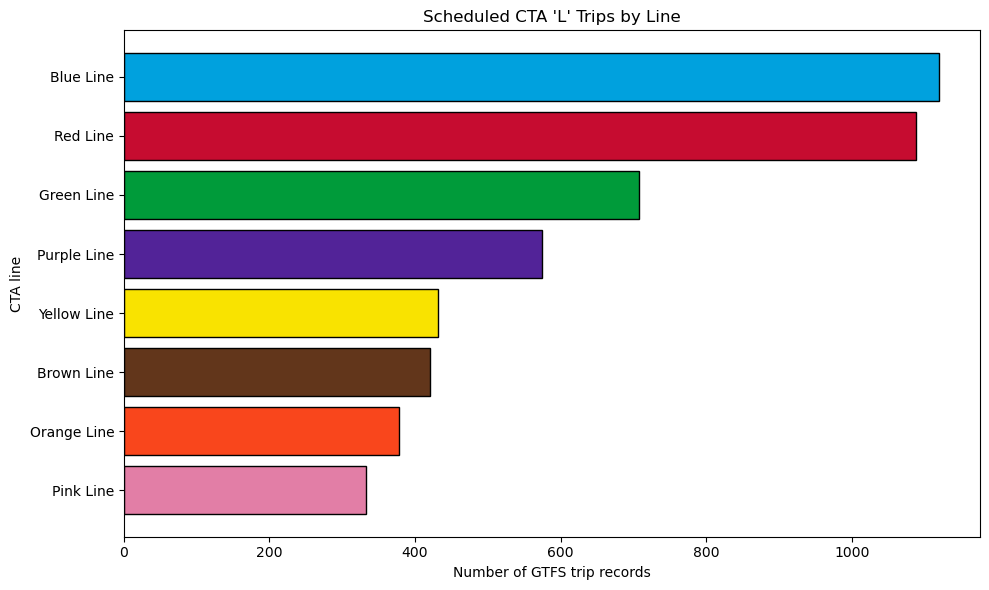

In [12]:

# Add # so matplotlib recognizes GTFS hexadecimal colors
trips_by_line["plot_color"] = (
    "#" + trips_by_line["route_color"].fillna("808080")
)

plt.figure(figsize=(10, 6))

plt.barh(
    trips_by_line["route_long_name"],
    trips_by_line["scheduled_trips"],
    color=trips_by_line["plot_color"],
    edgecolor="black",
)

plt.title("Scheduled CTA 'L' Trips by Line")
plt.xlabel("Number of GTFS trip records")
plt.ylabel("CTA line")

plt.tight_layout()
plt.show()

In [13]:
# Make latitude and longitude numeric
l_stops["stop_lat"] = pd.to_numeric(
    l_stops["stop_lat"],
    errors="coerce",
)

l_stops["stop_lon"] = pd.to_numeric(
    l_stops["stop_lon"],
    errors="coerce",
)


# Connect stops to trips, then trips to routes
stop_line_data = (
    l_stop_times[
        ["trip_id", "stop_id"]
    ]
    .merge(
        l_trips[
            ["trip_id", "route_id"]
        ],
        on="trip_id",
        how="left",
    )
    .merge(
        l_routes[
            [
                "route_id",
                "route_short_name",
                "route_long_name",
                "route_color",
            ]
        ],
        on="route_id",
        how="left",
    )
    .merge(
        l_stops[
            [
                "stop_id",
                "stop_name",
                "stop_lat",
                "stop_lon",
            ]
        ],
        on="stop_id",
        how="left",
    )
)


# Remove repeated trip-stop combinations
mapped_stops = (
    stop_line_data
    .dropna(
        subset=[
            "stop_lat",
            "stop_lon",
            "route_color",
        ]
    )
    .drop_duplicates(
        subset=[
            "stop_id",
            "route_id",
        ]
    )
)

In [14]:
cta_map = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11,
    tiles="CartoDB positron",
)

for _, stop in mapped_stops.iterrows():

    line_color = "#" + stop["route_color"]

    line_name = (
        stop["route_long_name"]
        if pd.notna(stop["route_long_name"])
        else stop["route_short_name"]
    )

    folium.CircleMarker(
        location=[
            stop["stop_lat"],
            stop["stop_lon"],
        ],
        radius=5,
        popup=(
            f"<b>{stop['stop_name']}</b><br>"
            f"{line_name}"
        ),
        tooltip=(
            f"{stop['stop_name']} — {line_name}"
        ),
        color=line_color,
        fill=True,
        fill_color=line_color,
        fill_opacity=0.9,
        weight=2,
    ).add_to(cta_map)

cta_map

In [15]:
shapes = pd.read_csv(
    GTFS_FOLDER / "shapes.txt",
    dtype=str,
)

print(shapes.head())
print(shapes.columns.tolist())

   shape_id shape_pt_lat shape_pt_lon shape_pt_sequence shape_dist_traveled
0  67900095    41.911304   -87.631222                 1                   0
1  67900095    41.911304   -87.631222                 2                  49
2  67900095     41.91118    -87.63129                 3                 106
3  67900095     41.91118     -87.6315                 4                 157
4  67900095     41.91118    -87.63169                 5                 224
['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence', 'shape_dist_traveled']


In [16]:

# --------------------------------------------------
# 1. Prepare shape coordinates and sequence numbers
# --------------------------------------------------

shapes["shape_pt_lat"] = pd.to_numeric(
    shapes["shape_pt_lat"],
    errors="coerce",
)

shapes["shape_pt_lon"] = pd.to_numeric(
    shapes["shape_pt_lon"],
    errors="coerce",
)

shapes["shape_pt_sequence"] = pd.to_numeric(
    shapes["shape_pt_sequence"],
    errors="coerce",
)


# --------------------------------------------------
# 2. Connect each L shape to its route and color
# --------------------------------------------------

l_shape_routes = (
    l_trips[
        ["route_id", "shape_id"]
    ]
    .dropna(subset=["shape_id"])
    .drop_duplicates()
    .merge(
        l_routes[
            [
                "route_id", 
                "route_long_name",
                "route_color",
            ]
        ],
        on="route_id",
        how="left",
        validate="many_to_one",
    )
)

print(l_shape_routes.head())

  route_id   shape_id route_long_name route_color
0     Blue  309100002       Blue Line      00A1DE
1     Blue  309100074       Blue Line      00A1DE
2     Blue  309100005       Blue Line      00A1DE
3     Blue  309100040       Blue Line      00A1DE
4     Blue  309100129       Blue Line      00A1DE


In [17]:
cta_map = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11,
    tiles="CartoDB positron",
)


# --------------------------------------------------
# 3. Draw each L route shape
# --------------------------------------------------

for _, shape_route in l_shape_routes.iterrows():

    shape_points = (
        shapes[
            shapes["shape_id"] == shape_route["shape_id"]
        ]
        .dropna(
            subset=[
                "shape_pt_lat",
                "shape_pt_lon",
                "shape_pt_sequence",
            ]
        )
        .sort_values("shape_pt_sequence")
    )

    # Skip empty or invalid shapes
    if len(shape_points) < 2:
        continue

    coordinates = shape_points[
        ["shape_pt_lat", "shape_pt_lon"]
    ].values.tolist()

    route_color = shape_route["route_color"]

    if pd.isna(route_color) or route_color == "":
        route_color = "#555555"
    else:
        route_color = "#" + route_color.lstrip("#")

    line_name = shape_route["route_long_name"]

    if pd.isna(line_name) or line_name == "":
        line_name = shape_route["route_short_name"]

    folium.PolyLine(
        locations=coordinates,
        color=route_color,
        weight=5,
        opacity=0.85,
        tooltip=line_name,
    ).add_to(cta_map)

In [18]:
# Connect stops to routes
stop_line_data = (
    l_stop_times[
        ["trip_id", "stop_id"]
    ]
    .merge(
        l_trips[
            ["trip_id", "route_id"]
        ],
        on="trip_id",
        how="left",
    )
    .merge(
        l_routes[
            [
                "route_id",
                "route_short_name",
                "route_long_name",
                "route_color",
            ]
        ],
        on="route_id",
        how="left",
    )
    .merge(
        l_stops[
            [
                "stop_id",
                "stop_name",
                "stop_lat",
                "stop_lon",
            ]
        ],
        on="stop_id",
        how="left",
    )
)

# Remove repeated stop-line combinations
mapped_stops = (
    stop_line_data
    .dropna(
        subset=[
            "stop_lat",
            "stop_lon",
        ]
    )
    .drop_duplicates(
        subset=[
            "stop_id",
            "route_id",
        ]
    )
)

# Group all lines serving the same station location
station_lines = (
    mapped_stops
    .groupby(
        [
            "stop_name",
            "stop_lat",
            "stop_lon",
        ],
        as_index=False,
    )
    .agg(
        lines=(
            "route_long_name",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        colors=(
            "route_color",
            lambda values: list(
                dict.fromkeys(
                    values.dropna()
                )
            ),
        ),
    )
)

print(station_lines.head())

            stop_name   stop_lat   stop_lon          lines    colors
0                18th  41.857908 -87.669147    [Pink Line]  [E27EA6]
1  35-Bronzeville-IIT  41.831677 -87.625826   [Green Line]  [009B3A]
2         35th/Archer  41.829353 -87.680622  [Orange Line]  [F9461C]
3                43rd  41.816462 -87.619021   [Green Line]  [009B3A]
4          47th-Green  41.809209 -87.618826   [Green Line]  [009B3A]


In [19]:
# --------------------------------------------------
# 1. Helper functions
# --------------------------------------------------

def clean_route_colors(colors):
    """Convert GTFS route colors into valid hexadecimal colors."""
    return [
        "#" + str(color).lstrip("#")
        for color in colors
        if pd.notna(color) and str(color).strip() != ""
    ]


def get_marker_style(station_colors):
    """Choose station-marker styling."""
    is_transfer = len(station_colors) > 1

    if is_transfer:
        return {
            "is_transfer": True,
            "border": "#222222",
            "fill": "#ffffff",
            "radius": 6,
            "weight": 3,
        }

    if station_colors:
        return {
            "is_transfer": False,
            "border": station_colors[0],
            "fill": station_colors[0],
            "radius": 4,
            "weight": 2,
        }

    return {
        "is_transfer": False,
        "border": "#666666",
        "fill": "#666666",
        "radius": 4,
        "weight": 2,
    }


def make_station_label(station_name, rotation=0):
    """Create a permanent station label."""
    return folium.DivIcon(
        icon_size=(150, 22),
        icon_anchor=(-8, 7),
        class_name="station-name-label",
        html=f"""
        <div
            class="station-label-text"
            style="
                transform: rotate({rotation}deg);
                transform-origin: left center;
            "
        >
            {station_name}
        </div>
        """,
    )


def get_station_display_settings(
    original_station_name,
    line_names,
):
    """
    Return the visible map name and label rotation.

    Stations not listed in station_display_config keep
    their original GTFS name and remain horizontal.
    """

    display_name = original_station_name
    rotation = 0

    for line_name in line_names:
        config_key = (
            original_station_name,
            line_name,
        )

        if config_key in station_display_config:
            settings = station_display_config[config_key]

            display_name = settings.get(
                "display_name",
                original_station_name,
            )

            rotation = settings.get(
                "rotation",
                0,
            )

            break

    return display_name, rotation

 
 

In [20]:
# --------------------------------------------------
# 2. Add clean label styling
# --------------------------------------------------

label_css = """
<style>
.station-name-label {
    background: transparent !important;
    border: none !important;
}

.station-label-text {
    font-family: Arial, sans-serif;
    font-size: 9px;
    font-weight: 600;
    color: #202020;
    white-space: nowrap;
    line-height: 1;
    text-shadow:
        -1px -1px 0 #ffffff,
         1px -1px 0 #ffffff,
        -1px  1px 0 #ffffff,
         1px  1px 0 #ffffff,
         0px  0px 3px #ffffff;
}
</style>
"""

cta_map.get_root().html.add_child(
    folium.Element(label_css)
)

In [21]:
# --------------------------------------------------
# 3. Create map layers
# --------------------------------------------------

station_marker_layer = folium.FeatureGroup(
    name="Stations",
    show=True,
)

station_label_layer = folium.FeatureGroup(
    name="Station names",
    show=True,
)

In [22]:
# --------------------------------------------------
# Station display configuration
# --------------------------------------------------
# Key:
#     (original GTFS station name, CTA line name)
#
# Values:
#     display_name = name shown on the map
#     rotation = label rotation in degrees
#
# -45 degrees = 45 degrees counterclockwise

station_display_config = {
    # --------------------------------------------------
    # Red Line
    # --------------------------------------------------
    ("Grand-Red", "Red Line"): {
        "display_name": "Grand/State",
        "rotation": 0,
    },

    ("Chicago-Red", "Red Line"): {
        "display_name": "Chicago/State",
        "rotation": 0,
    },

    
    ("Clark/Division", "Red Line"): {
        "display_name": "Clark/Division",
        "rotation": -45,
    },

    ("North/Clybourn", "Red Line"): {
        "display_name": "North/Clybourn",
        "rotation": -45,
    },

    ("Belmont", "Red Line"): {
        "display_name": "Belmont/Lakeview",
        "rotation": 0,
    },

    ("Addison-Red", "Red Line"): {
        "display_name": "Wrigley Field",
        "rotation": 0,
    },

    # --------------------------------------------------
    # Red Line — Dan Ryan branch
    # --------------------------------------------------
    
    ("Cermak-Chinatown", "Red Line"): {
        "display_name": "Cermak-Chinatown",
        "rotation": -45,
    },
    ("Sox-35th", "Red Line"): {
        "display_name": "Sox-35th",
        "rotation": -45,
    },
    ("47th-Red", "Red Line"): {
        "display_name": "47th/Dan Ryan",
        "rotation": -45,
    },
    ("Garfield-Red", "Red Line"): {
        "display_name": "Garfield/Dan Ryan",
        "rotation": -45,
    },
    ("63rd", "Red Line"): {
        "display_name": "63rd/Dan Ryan",
        "rotation": -45,
    },
    ("69th", "Red Line"): {
        "display_name": "69th/Dan Ryan",
        "rotation": 0,
    },
    ("79th", "Red Line"): {
        "display_name": "79th/Dan Ryan",
        "rotation": 0,
    },
    ("87th", "Red Line"): {
        "display_name": "87th/Dan Ryan",
        "rotation": 0,
    },
    ("95th", "Red Line"): {
        "display_name": "95th/Dan Ryan",
        "rotation": 0,
    },

    # --------------------------------------------------
    # Blue Line — Forest Park / Eisenhower branch
    # --------------------------------------------------
    ("Forest Park", "Blue Line"): {
        "display_name": "Forest Park/Eisenhower",
        "rotation": -45,
    },
    ("Harlem-Forest Park", "Blue Line"): {
        "display_name": "Harlem/Eisenhower",
        "rotation": -45,
    },
    ("Oak Park-Blue", "Blue Line"): {
        "display_name": "Oak Park/Eisenhower",
        "rotation": -45,
    },
    ("Austin-Blue", "Blue Line"): {
        "display_name": "Austin/Eisenhower",
        "rotation": -45,
    },
    ("Cicero-Forest Park", "Blue Line"): {
        "display_name": "Cicero/Eisenhower",
        "rotation": -45,
    },
    ("Pulaski-Forest Park", "Blue Line"): {
        "display_name": "Pulaski/Eisenhower",
        "rotation": -45,
    },
    ("Kedzie-Homan", "Blue Line"): {
        "display_name": "Kedzie-Homan",
        "rotation": -45,
    },
    ("Western-Forest Park", "Blue Line"): {
        "display_name": "Western/Eisenhower",
        "rotation": -45,
    },
    ("Illinois Medical District", "Blue Line"): {
        "display_name": "Illinois Medical District",
        "rotation": -45,
    },
    ("Racine", "Blue Line"): {
        "display_name": "Racine/Eisenhower",
        "rotation": -45,
    },
    ("UIC-Halsted", "Blue Line"): {
        "display_name": "UIC-Halsted",
        "rotation": -45,
    },
    ("Clinton-Blue", "Blue Line"): {
        "display_name": "Clinton/Eisenhower",
        "rotation": -45,
    },

    # --------------------------------------------------
    # Blue Line — Milwaukee Subway
    # --------------------------------------------------
    ("California-O'Hare", "Blue Line"): {
        "display_name": "California/Milwaukee",
        "rotation": -45,
    },
    ("Western-O'Hare", "Blue Line"): {
        "display_name": "Western/Milwaukee",
        "rotation": -45,
    },
    ("Damen-O'Hare", "Blue Line"): {
        "display_name": "Damen/Milwaukee/North",
        "rotation": -45,
    },
    
    ("Division", "Blue Line"): {
        "display_name": "Division/Milwaukee",
        "rotation": -45,
    },
    ("Chicago-Blue", "Blue Line"): {
        "display_name": "Chicago/Milwaukee",
        "rotation": -45,
    },
    ("Grand-Blue", "Blue Line"): {
        "display_name": "Grand/Milwaukee",
        "rotation": -45,
    },
    
    # --------------------------------------------------
    # Blue Line — Dearborn subway
    # --------------------------------------------------
    
    ("Clark/Lake (Subway)", "Blue Line"): {
        "display_name": "Clark/Lake",
        "rotation": -90,
    },
    ("Washington-Blue", "Blue Line"): {
        "display_name": "Washington/Dearborn",
        "rotation": 0,
    },
    ("Monroe-Blue", "Blue Line"): {
        "display_name": "Monroe/Dearborn",
        "rotation": 0,
    },
    ("Jackson-Blue", "Blue Line"): {
        "display_name": "Jackson",
        "rotation": 0,
    },
    ("LaSalle", "Blue Line"): {
        "display_name": "LaSalle/Ida",
        "rotation": 0,
    },
    

    # Blue Line — selected O'Hare branch sections
    ("Logan Square", "Blue Line"): {
        "display_name": "Logan Square",
        "rotation": -45,
    },
    
    ("Belmont-Blue", "Blue Line"): {
        "display_name": "Belmont/Avondale",
        "rotation": -45,
    },
    ("Addison-Blue", "Blue Line"): {
        "display_name": "Addison/Kennedy",
        "rotation": -45,
    },
    ("Irving Park-Blue", "Blue Line"): {
        "display_name": "Irving Park/Kennedy",
        "rotation": -45,
    },
    
    ("Montrose-Blue", "Blue Line"): {
        "display_name": "Mayfair",
        "rotation": -45,
    },

    ("Jefferson Park", "Blue Line"): {
        "display_name": "Jefferson Park",
        "rotation": -45,
    },
    
    ("Harlem-O'Hare", "Blue Line"): {
        "display_name": "Harlem/Kennedy",
        "rotation": -45,
    },
    ("Cumberland", "Blue Line"): {
        "display_name": "Cumberland/Kennedy",
        "rotation": -45,
    },
    ("Rosemont", "Blue Line"): {
        "display_name": "Rosemont/Kennedy",
        "rotation": -45,
    },
    ("O'Hare", "Blue Line"): {
        "display_name": "O'Hare ✈️",
        "rotation": -45,
    },

    # --------------------------------------------------
    # Green Line — Lake Street branch
    # --------------------------------------------------
    ("Harlem-Green", "Green Line"): {
        "display_name": "Harlem/Lake",
        "rotation": -45,
    },
    ("Oak Park-Green", "Green Line"): {
        "display_name": "Oak Park/Lake",
        "rotation": -45,
    },
    ("Ridgeland", "Green Line"): {
        "display_name": "Ridgeland/Lake",
        "rotation": -45,
    },
    ("Austin-Green", "Green Line"): {
        "display_name": "Austin/Lake",
        "rotation": -45,
    },
    ("Central-Green", "Green Line"): {
        "display_name": "Central/Lake",
        "rotation": -45,
    },
    ("Laramie", "Green Line"): {
        "display_name": "Laramie/Lake",
        "rotation": -45,
    },
    ("Cicero-Green", "Green Line"): {
        "display_name": "Cicero/Lake",
        "rotation": -45,
    },
    ("Pulaski-Green", "Green Line"): {
        "display_name": "Pulaski/Lake",
        "rotation": -45,
    },
    ("Conservatory", "Green Line"): {
        "display_name": "Conservatory-Central Park Drive",
        "rotation": -45,
    },
    ("Kedzie-Green", "Green Line"): {
        "display_name": "Kedzie/Lake",
        "rotation": -45,
    },
    ("California-Green", "Green Line"): {
        "display_name": "California/Lake",
        "rotation": -45,
    },
    ("Damen-Green", "Green Line"): {
        "display_name": "Damen/Lake",
        "rotation": -45,
    },
    ("Ashland-Lake", "Green Line"): {
        "display_name": "Ashland/Lake",
        "rotation": -45,
    },
    ("Morgan", "Green Line"): {
        "display_name": "Morgan/Lake",
        "rotation": -45,
    },
    ("Clinton-Green", "Green Line"): {
        "display_name": "Clinton/Lake",
        "rotation": -45,
    },

    ("Cermak-McCormick Place", "Green Line"): {
        "display_name": "Cermak-McCormick Place",
        "rotation": -45,
    },

    ("35th-Bronzeville-IIT", "Green Line"): {
    "display_name": "35th-Bronzeville-IIT",
    "rotation": -45,
    },
    ("Indiana", "Green Line"): {
        "display_name": "Indiana/South Side",
        "rotation": 0,
    },
    ("43rd", "Green Line"): {
        "display_name": "43rd/South Side",
        "rotation": 0,
    },
    ("47th-Green", "Green Line"): {
        "display_name": "47th/South Side",
        "rotation": 0,
    },
    ("51st", "Green Line"): {
        "display_name": "51st/South Side",
        "rotation": 0,
    },
    ("Garfield-Green", "Green Line"): {
        "display_name": "Garfield/South Side",
        "rotation": 0,
    },


    # Green Line — 63rd Street branches
    ("Halsted-Green", "Green Line"): {
        "display_name": "63rd/Halsted",
        "rotation": -45,
    },
    
    ("Ashland/63rd", "Green Line"): {
        "display_name": "63rd/Ashland",
        "rotation": -45,
    },
    ("King Drive", "Green Line"): {
        "display_name": "63rd/King Drive",
        "rotation": -45,
    },
    ("East 63rd-Cottage Grove", "Green Line"): {
        "display_name": "63rd/Cottage Grove",
        "rotation": -45,
    },

    # --------------------------------------------------
    # Purple Line — Evanston branch
    # --------------------------------------------------
    
    
    ("Central-Purple", "Purple Line"): {
        "display_name": "Central/Evanston",
        "rotation": 0,
    },
    ("Noyes", "Purple Line"): {
        "display_name": "Noyes/Evanston",
        "rotation": 0,
    },
    ("Foster", "Purple Line"): {
        "display_name": "Foster/Evanston",
        "rotation": 0,
    },
    ("Davis", "Purple Line"): {
        "display_name": "Davis/Evanston",
        "rotation": 0,
    },
    ("Dempster", "Purple Line"): {
        "display_name": "Dempster/Evanston",
        "rotation": 0,
    },
    ("Main", "Purple Line"): {
        "display_name": "Main/Evanston",
        "rotation": 0,
    },
    ("South Boulevard", "Purple Line"): {
        "display_name": "South Boulevard/Evanston",
        "rotation": 0,
    },

    # --------------------------------------------------
    # Pink Line
    # --------------------------------------------------
    ("54th/Cermak", "Pink Line"): {
        "display_name": "54th/Cermak",
        "rotation": -45,
    },
    ("Cicero-Cermak", "Pink Line"): {
        "display_name": "Cicero/Cermak",
        "rotation": -45,
    },
    ("Kostner", "Pink Line"): {
        "display_name": "Kostner/Cermak",
        "rotation": -45,
    },
    ("Pulaski-Cermak", "Pink Line"): {
        "display_name": "Pulaski/Cermak",
        "rotation": -45,
    },
    ("Central Park", "Pink Line"): {
        "display_name": "Central Park/Cermak",
        "rotation": -45,
    },
    ("Kedzie-Cermak", "Pink Line"): {
        "display_name": "Kedzie/Cermak",
        "rotation": -45,
    },
    ("California-Cermak", "Pink Line"): {
        "display_name": "California/Cermak",
        "rotation": -45,
    },
    ("Western-Cermak", "Pink Line"): {
        "display_name": "Western/Cermak",
        "rotation": -45,
    },
    ("Damen-Cermak", "Pink Line"): {
        "display_name": "Damen/Cermak",
        "rotation": -45,
    },

    # --------------------------------------------------
    # Orange Line — selected east–west section
    # --------------------------------------------------
    ("Halsted-Orange", "Orange Line"): {
        "display_name": "Halsted/Archer",
        "rotation": 0,
    },
    ("Ashland-Orange", "Orange Line"): {
        "display_name": "Ashland/Archer",
        "rotation": 0,
    },

    ("35th/Archer", "Orange Line"): {
        "display_name": "35th/Archer",
        "rotation": 0,
    },
    
    ("Western-Orange", "Orange Line"): {
        "display_name": "Western/Archer",
        "rotation": 0,
    },
    ("Kedzie-Orange", "Orange Line"): {
        "display_name": "Kedzie/Archer",
        "rotation": -90,
    },
    ("Pulaski-Orange", "Orange Line"): {
        "display_name": "Pulaski/Archer",
        "rotation": -90,
    },

    ("Midway", "Orange Line"): {
        "display_name": "Midway ✈️",
        "rotation": 0,
    },

    # --------------------------------------------------
    # Brown Line — selected east–west section
    # --------------------------------------------------
    ("Southport", "Brown Line"): {
        "display_name": "Southport",
        "rotation": -45,
    },
    ("Paulina", "Brown Line"): {
        "display_name": "Paulina",
        "rotation": -45,
    },

    ("Addison-Brown", "Brown Line"): {
        "display_name": "Addison/North Center",
        "rotation": -45,
    },

    ("Irving Park-Brown", "Brown Line"): {
        "display_name": "Irving Park/North Center",
        "rotation": -45,
    },

    ("Montrose-Brown", "Brown Line"): {
        "display_name": "Montrose/Ravenswood",
        "rotation": -45,
    },
    ("Damen-Brown", "Brown Line"): {
        "display_name": "Damen/Ravenswood",
        "rotation": -45,
    },
    ("Western-Brown", "Brown Line"): {
        "display_name": "Western/Lincoln Square",
        "rotation": -45,
    },
    ("Rockwell", "Brown Line"): {
        "display_name": "Rockwell/Lincoln Square",
        "rotation": -45,
    },
    ("Francisco", "Brown Line"): {
        "display_name": "Francisco/Ravenswood",
        "rotation": -45,
    },
    ("Kedzie-Brown", "Brown Line"): {
        "display_name": "Kedzie/Albany Park",
        "rotation": -45,
    },
    ("Kimball", "Brown Line"): {
        "display_name": "Kimball/Albany Park",
        "rotation": -45,
    },
}

In [23]:
problem_stations = station_lines[
    station_lines["stop_name"].str.contains(
        "Jackson|Clark/Lake|Wilson|Roosevelt",
        case=False,
        na=False,
    )
]

print(
    problem_stations[
        [
            "stop_name",
            "lines",
            "colors",
        ]
    ].to_string(index=False)
)

            stop_name                                                         lines                                   colors
Clark/Lake (Elevated) [Brown Line, Green Line, Orange Line, Pink Line, Purple Line] [009B3A, F9461C, 62361B, E27EA6, 522398]
  Clark/Lake (Subway)                                                   [Blue Line]                                 [00A1DE]
         Jackson-Blue                                                   [Blue Line]                                 [00A1DE]
          Jackson-Red                                                    [Red Line]                                 [C60C30]
 Roosevelt (Elevated)                                     [Green Line, Orange Line]                         [009B3A, F9461C]
   Roosevelt (Subway)                                                    [Red Line]                                 [C60C30]
   Wilson-North Inner                                                    [Red Line]                                 [C60C30]


In [24]:
# --------------------------------------------------
# Consolidate split CTA station complexes
# --------------------------------------------------

station_complex_aliases = {
    # Clark/Lake
    "Clark/Lake (Elevated)": "Clark/Lake",
    "Clark/Lake (Subway)": "Clark/Lake",

    # Jackson
    "Jackson-Blue": "Jackson",
    "Jackson-Red": "Jackson",

    # Roosevelt
    "Roosevelt (Elevated)": "Roosevelt",
    "Roosevelt (Subway)": "Roosevelt",

    # Wilson
    "Wilson-North Inner": "Wilson",
    "Wilson-North Outer": "Wilson",
    "Wilson-South Inner": "Wilson",
    "Wilson-South Outer": "Wilson",
}

In [25]:
station_lines["station_complex_name"] = (
    station_lines["stop_name"]
    .replace(station_complex_aliases)
)

In [26]:
station_lines = (
    station_lines
    .groupby(
        "station_complex_name",
        as_index=False,
    )
    .agg(
        # Use the average location of all related station records
        stop_lat=(
            "stop_lat",
            "mean",
        ),
        stop_lon=(
            "stop_lon",
            "mean",
        ),

        # Combine every line serving the station complex
        lines=(
            "lines",
            lambda groups: sorted(
                {
                    line
                    for group in groups
                    for line in group
                }
            ),
        ),

        # Combine all route colors without duplicates
        colors=(
            "colors",
            lambda groups: list(
                dict.fromkeys(
                    color
                    for group in groups
                    for color in group
                )
            ),
        ),
    )
    .rename(
        columns={
            "station_complex_name": "stop_name",
        }
    )
)

In [27]:
# --------------------------------------------------
# 5. Add station markers and labels
# --------------------------------------------------
ellipse_transfer_stations = {
    "Jackson",
    "Roosevelt",
}

for _, station in station_lines.iterrows():

    original_station_name = station["stop_name"]
    station_lat = station["stop_lat"]
    station_lon = station["stop_lon"]

    line_names = [
        str(line)
        for line in station["lines"]
        if pd.notna(line)
    ]

    station_name, label_rotation = (
        get_station_display_settings(
            original_station_name,
            line_names,
        )
    )

    station_colors = clean_route_colors(
        station["colors"]
    )

    marker_style = get_marker_style(
        station_colors
    )

    line_text = "<br>".join(line_names)

    tooltip_text = (
        f"{station_name} — {', '.join(line_names)}"
        if line_names
        else station_name
    )

 
    folium.CircleMarker(
        location=[
            station_lat,
            station_lon,
        ],
        radius=marker_style["radius"],
        color=marker_style["border"],
        fill=True,
        fill_color=marker_style["fill"],
        fill_opacity=1,
        weight=marker_style["weight"],
        tooltip=tooltip_text,
        popup=folium.Popup(
            html=(
                f"<b>{station_name}</b><br>"
                f"{line_text}"
            ),
            max_width=250,
        ),
    ).add_to(station_marker_layer)

    folium.Marker(
        location=[
            station_lat,
            station_lon,
        ],
        icon=make_station_label(
            station_name,
            rotation=label_rotation,
        ),
        interactive=False,
    ).add_to(station_label_layer)




In [28]:
# --------------------------------------------------
# 6. Add layers to map
# --------------------------------------------------

station_marker_layer.add_to(cta_map)
station_label_layer.add_to(cta_map)

folium.LayerControl(
    collapsed=True
).add_to(cta_map)


# --------------------------------------------------
# 7. Display map
# --------------------------------------------------
# cta_map

In [29]:
cta_map_english = cta_map

In [30]:
cta_map_english.save("outputs/cta_map_english.html")

In [31]:
problem_stations = station_lines[
    station_lines["stop_name"].str.contains(
        "Jackson|Clark/Lake|Wilson",
        case=False,
        na=False,
    )
]

print(
    problem_stations[
        [
            "stop_name",
            "lines",
            "colors",
        ]
    ].to_string(index=False)
)

 stop_name                                                                    lines                                           colors
Clark/Lake [Blue Line, Brown Line, Green Line, Orange Line, Pink Line, Purple Line] [009B3A, F9461C, 62361B, E27EA6, 522398, 00A1DE]
   Jackson                                                    [Blue Line, Red Line]                                 [00A1DE, C60C30]
    Wilson                                                  [Purple Line, Red Line]                                 [C60C30, 522398]


# Korean Translation

In [32]:
# ============================================================
# CTA KOREAN MAP
# Translate the finalized English CTA map into Korean
# ============================================================
 
# ============================================================
# 1. FINAL ENGLISH STATION NAME -> KOREAN STATION NAME
# ============================================================

station_korean_name_map = {

    # --------------------------------------------------------
    # Numeric / South Side / Dan Ryan
    # --------------------------------------------------------
    "18th": "18번가",
    "35-Bronzeville-IIT": "35번가-브론즈빌-IIT",
    "35th/Archer": "35번가/아처",
    "43rd/South Side": "43번가/사우스 사이드",
    "47th/Dan Ryan": "47번가/댄 라이언",
    "47th/South Side": "47번가/사우스 사이드",
    "51st/South Side": "51번가/사우스 사이드",
    "54th/Cermak": "54번가/서맥",
    "63rd/Ashland": "63번가/애슐랜드",
    "63rd/Cottage Grove": "63번가/코티지 그로브",
    "63rd/Dan Ryan": "63번가/댄 라이언",
    "63rd/Halsted": "63번가/할스테드",
    "63rd/King Drive": "63번가/킹 드라이브",
    "69th/Dan Ryan": "69번가/댄 라이언",
    "79th/Dan Ryan": "79번가/댄 라이언",
    "87th/Dan Ryan": "87번가/댄 라이언",
    "95th/Dan Ryan": "95번가/댄 라이언",

    # --------------------------------------------------------
    # A
    # --------------------------------------------------------
    "Adams/Wabash": "애덤스/워배시",
    "Addison/Kennedy": "애디슨/케네디",
    "Addison/North Center": "애디슨/노스 센터",
    "Argyle": "아가일",
    "Armitage": "아미티지",
    "Ashland/Archer": "애슐랜드/아처",
    "Ashland/Lake": "애슐랜드/레이크",
    "Austin/Eisenhower": "오스틴/아이젠하워",
    "Austin/Lake": "오스틴/레이크",

    # --------------------------------------------------------
    # B
    # --------------------------------------------------------
    "Belmont/Avondale": "벨몬트/에이번데일",
    "Belmont/Lakeview": "벨몬트/레이크뷰",
    "Berwyn": "버윈",
    "Bryn Mawr": "브린 모어",

    # --------------------------------------------------------
    # C
    # --------------------------------------------------------
    "California/Cermak": "캘리포니아/서맥",
    "California/Lake": "캘리포니아/레이크",
    "California/Milwaukee": "캘리포니아/밀워키",

    "Central Park/Cermak": "센트럴 파크/서맥",
    "Central/Evanston": "센트럴/에반스턴",
    "Central/Lake": "센트럴/레이크",

    "Cermak-Chinatown": "서맥-차이나타운",
    "Cermak-McCormick Place": "서맥-맥코믹 플레이스",

    "Chicago-Brown": "시카고",
    "Chicago/Milwaukee": "시카고/밀워키",
    "Chicago/State": "시카고/스테이트",

    "Cicero/Cermak": "시세로/서맥",
    "Cicero/Eisenhower": "시세로/아이젠하워",
    "Cicero/Lake": "시세로/레이크",

    "Clark/Division": "클라크/디비전",
    "Clark/Lake": "클라크/레이크",

    "Clinton/Eisenhower": "클린턴/아이젠하워",
    "Clinton/Lake": "클린턴/레이크",

    "Conservatory-Central Park Drive":
        "컨서버토리-센트럴 파크 드라이브",

    "Cumberland/Kennedy": "컴벌랜드/케네디",

    # --------------------------------------------------------
    # D
    # --------------------------------------------------------
    "Damen/Cermak": "데이먼/서맥",
    "Damen/Lake": "데이먼/레이크",
    "Damen/Milwaukee/North": "데이먼/밀워키/노스",
    "Damen/Ravenswood": "데이먼/레이븐스우드",

    "Davis/Evanston": "데이비스/에반스턴",
    "Dempster-Skokie": "뎀스터-스코키",
    "Dempster/Evanston": "뎀스터/에반스턴",

    "Diversey": "다이버시",
    "Division/Milwaukee": "디비전/밀워키",

    # --------------------------------------------------------
    # F
    # --------------------------------------------------------
    "Forest Park/Eisenhower": "포리스트 파크/아이젠하워",
    "Foster/Evanston": "포스터/에반스턴",
    "Francisco/Ravenswood": "프란시스코/레이븐스우드",
    "Fullerton": "풀러턴",

    # --------------------------------------------------------
    # G
    # --------------------------------------------------------
    "Garfield/Dan Ryan": "가필드/댄 라이언",
    "Garfield/South Side": "가필드/사우스 사이드",

    "Grand/Milwaukee": "그랜드/밀워키",
    "Grand/State": "그랜드/스테이트",

    "Granville": "그랜빌",

    # --------------------------------------------------------
    # H
    # --------------------------------------------------------
    "Halsted/Archer": "할스테드/아처",
    "Harlem/Eisenhower": "할렘/아이젠하워",
    "Harlem/Kennedy": "할렘/케네디",
    "Harlem/Lake": "할렘/레이크",

    "Harold Washington Library":
        "해럴드 워싱턴 도서관",

    "Harrison": "해리슨",
    "Howard": "하워드",

    # --------------------------------------------------------
    # I
    # --------------------------------------------------------
    "Illinois Medical District": "일리노이 의료지구",

    "Indiana/South Side": "인디애나/사우스 사이드",

    "Irving Park/Kennedy": "어빙 파크/케네디",
    "Irving Park/North Center": "어빙 파크/노스 센터",

    # --------------------------------------------------------
    # J
    # --------------------------------------------------------
    "Jackson": "잭슨",
    "Jarvis": "자비스",
    "Jefferson Park": "제퍼슨 파크",

    # --------------------------------------------------------
    # K
    # --------------------------------------------------------
    "Kedzie-Homan": "케지-호먼",
    "Kedzie/Albany Park": "케지/올버니 파크",
    "Kedzie/Archer": "케지/아처",
    "Kedzie/Cermak": "케지/서맥",
    "Kedzie/Lake": "케지/레이크",

    "Kimball/Albany Park": "킴볼/올버니 파크",

    "Kostner/Cermak": "코스트너/서맥",

    # --------------------------------------------------------
    # L
    # --------------------------------------------------------
    "LaSalle/Ida": "라살/아이다",
    "LaSalle/Van Buren": "라살/밴 뷰런",

    "Lake": "레이크",
    "Laramie/Lake": "래러미/레이크",

    "Lawrence": "로렌스",
    "Linden": "린든",
    "Logan Square": "로건 스퀘어",
    "Loyola": "로욜라",

    # --------------------------------------------------------
    # M
    # --------------------------------------------------------
    "Main/Evanston": "메인/에반스턴",
    "Mayfair": "메이페어",

    "Merchandise Mart": "머천다이즈 마트",

    "Midway": "미드웨이",

    "Monroe-Red": "먼로",
    "Monroe/Dearborn": "먼로/디어본",

    "Montrose/Ravenswood": "몬트로즈/레이븐스우드",
    "Morgan/Lake": "모건/레이크",
    "Morse": "모스",

    # --------------------------------------------------------
    # N
    # --------------------------------------------------------
    "North/Clybourn": "노스/클라이본",
    "Noyes/Evanston": "노이스/에반스턴",

    # --------------------------------------------------------
    # O
    # --------------------------------------------------------
    "O'Hare ✈️": "오헤어",

    "Oak Park/Eisenhower": "오크 파크/아이젠하워",
    "Oak Park/Lake": "오크 파크/레이크",

    "Oakton-Skokie": "옥턴-스코키",

    # --------------------------------------------------------
    # P
    # --------------------------------------------------------
    "Paulina": "폴리나",
    "Polk": "포크",

    "Pulaski/Archer": "풀라스키/아처",
    "Pulaski/Cermak": "풀라스키/서맥",
    "Pulaski/Eisenhower": "풀라스키/아이젠하워",
    "Pulaski/Lake": "풀라스키/레이크",

    # --------------------------------------------------------
    # Q
    # --------------------------------------------------------
    "Quincy": "퀸시",

    # --------------------------------------------------------
    # R
    # --------------------------------------------------------
    "Racine/Eisenhower": "러신/아이젠하워",
    "Ridgeland/Lake": "리지랜드/레이크",

    "Rockwell/Lincoln Square": "록웰/링컨 스퀘어",

    "Roosevelt": "루스벨트",
    "Rosemont/Kennedy": "로즈몬트/케네디",

    # --------------------------------------------------------
    # S
    # --------------------------------------------------------
    "Sedgwick": "세지윅",
    "Sheridan": "셰리든",

    "South Boulevard/Evanston":
        "사우스 불러바드/에반스턴",

    "Southport": "사우스포트",
    "Sox-35th": "삭스-35번가",

    # --------------------------------------------------------
    # T
    # --------------------------------------------------------
    "Thorndale": "손데일",

    # --------------------------------------------------------
    # U
    # --------------------------------------------------------
    "UIC-Halsted": "UIC-할스테드",

    # --------------------------------------------------------
    # W
    # --------------------------------------------------------
    "Washington/Dearborn": "워싱턴/디어본",
    "Washington/Wabash": "워싱턴/워배시",
    "Washington/Wells": "워싱턴/웰스",

    "Wellington": "웰링턴",

    "Western/Archer": "웨스턴/아처",
    "Western/Cermak": "웨스턴/서맥",
    "Western/Eisenhower": "웨스턴/아이젠하워",
    "Western/Lincoln Square": "웨스턴/링컨 스퀘어",
    "Western/Milwaukee": "웨스턴/밀워키",

    "Wilson": "윌슨",
    "Wrigley Field": "리글리 필드",
}


# ============================================================
# 2. CTA LINE NAMES
# ============================================================

line_korean_name_map = {
    "Red Line": "레드 라인",
    "Blue Line": "블루 라인",
    "Brown Line": "브라운 라인",
    "Green Line": "그린 라인",
    "Orange Line": "오렌지 라인",
    "Pink Line": "핑크 라인",
    "Purple Line": "퍼플 라인",
    "Yellow Line": "옐로 라인",
}


# ============================================================
# 3. OPTIONAL GENERAL MAP WORDS
# ============================================================

map_text_korean = {
    "Stations": "역",
    "Station Labels": "역명",
}


# ============================================================
# 4. READ THE ALREADY-GENERATED ENGLISH MAP
# ============================================================

english_map_path = Path("outputs/cta_map_english.html")

korean_map_path = Path("outputs/cta_map_korean.html")

html = english_map_path.read_text(
    encoding="utf-8"
)


# ============================================================
# 5. TRANSLATE STATION NAMES
#
# IMPORTANT:
# Longest names first prevents something like:
#
#   Lake
#
# from being replaced before:
#
#   Clark/Lake
#
# ============================================================

for english_name in sorted(
    station_korean_name_map,
    key=len,
    reverse=True,
):

    korean_name = station_korean_name_map[
        english_name
    ]

    html = html.replace(
        english_name,
        korean_name,
    )


# ============================================================
# 6. TRANSLATE CTA LINE NAMES
# ============================================================

for english_line, korean_line in (
    line_korean_name_map.items()
):

    html = html.replace(
        english_line,
        korean_line,
    )


# ============================================================
# 7. TRANSLATE OTHER MAP TEXT
# ============================================================

for english_text, korean_text in (
    map_text_korean.items()
):

    html = html.replace(
        english_text,
        korean_text,
    )


# ============================================================
# 8. USE A KOREAN-FRIENDLY FONT STACK
# ============================================================

html = html.replace(
    "font-family: Arial, sans-serif;",
    """
    font-family:
        "Noto Sans KR",
        "Malgun Gothic",
        "Apple SD Gothic Neo",
        Arial,
        sans-serif;
    """,
)

# Special Folium escaped-name fix
html = html.replace(
    r"O\u0027Hare \u2708\ufe0f",
    "오헤어 ✈️",
)

# ============================================================
# 9. SAVE KOREAN MAP
# ============================================================

korean_map_path.write_text(
    html,
    encoding="utf-8",
)

print(
    f"Korean CTA map saved to: "
    f"{korean_map_path}"
)

Korean CTA map saved to: outputs\cta_map_korean.html
